# Random Forest

**Learning Objectives:**
- Train a Random Forest classifier and compare with a single Decision Tree
- Visualize feature importances
- Tune n_estimators, max_depth, and max_features with GridSearchCV

**Dataset:** Pima Indians Diabetes

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.ensemble import RandomForestClassifier
from sklearn import tree
import numpy as np

seed = 42

In [3]:
df = pd.read_csv('data/diabetes.csv')

train_set, test_set = train_test_split(df, test_size=0.2, random_state=seed)

X_train = train_set.drop(['Outcome'], axis=1)
y_train = train_set['Outcome']
X_test = test_set.drop(['Outcome'], axis=1)
y_test = test_set['Outcome']

### Baseline — Single Decision Tree

For comparison vs. the ensemble.

In [4]:
dt = tree.DecisionTreeClassifier(random_state=seed).fit(X_train, y_train)
y_preds_dt = dt.predict(X_test)
print(f'Decision Tree accuracy: {accuracy_score(y_test, y_preds_dt):.4f}')

Decision Tree accuracy: 0.6930


### Random Forest (Default)

Ensemble of trees trained on bootstrapped samples with random feature subsets. Reduces variance vs. single tree.

In [5]:
rf = RandomForestClassifier(random_state=seed).fit(X_train, y_train)
y_preds = rf.predict(X_test)
print(f'Random Forest accuracy: {accuracy_score(y_test, y_preds):.4f}')

Random Forest accuracy: 0.7368


### Feature Importances

Averaged across all trees in the forest.

                    feature  importance
1                   Glucose    0.258462
5                       BMI    0.180059
7                       Age    0.144415
6  DiabetesPedigreeFunction    0.106236
2             BloodPressure    0.090174
0               Pregnancies    0.078640
3             SkinThickness    0.072315
4                   Insulin    0.069700


Text(0.5, 1.0, 'Random Forest Feature Importances')

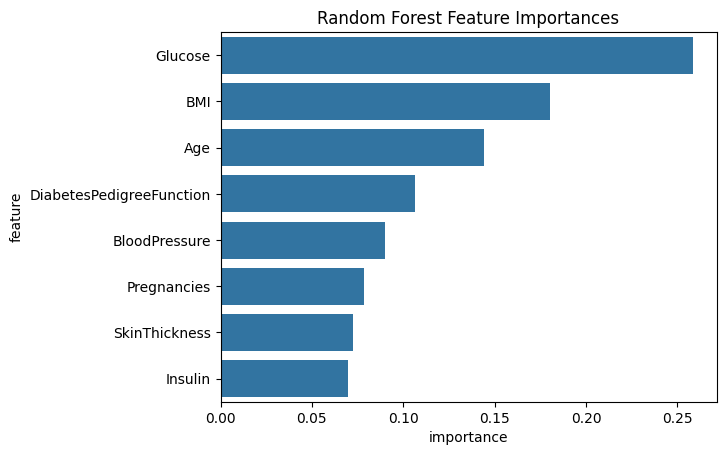

In [6]:
importances = pd.DataFrame({'feature': X_train.columns, 'importance': rf.feature_importances_})
importances.sort_values('importance', ascending=False, inplace=True)
print(importances)

sns.barplot(data=importances, x='importance', y='feature')
plt.title('Random Forest Feature Importances')

Glucose is by far the most important predictor, consistent with the single decision tree.

### Tuning n_estimators

More trees → lower variance, but diminishing returns and higher compute cost.

In [7]:
rf = RandomForestClassifier(random_state=seed)
parameters = {'n_estimators': [10, 50, 100, 300, 500]}

clf = GridSearchCV(rf, parameters, cv=5).fit(X_train, y_train)

In [8]:
print(f'Best n_estimators: {clf.best_params_}')
print(f'Best CV score: {clf.best_score_:.4f}')

Best n_estimators: {'n_estimators': 100}
Best CV score: 0.7511


In [9]:
y_preds = clf.predict(X_test)
print(f'Test accuracy: {accuracy_score(y_test, y_preds):.4f}')

Test accuracy: 0.7368


### Tune max_depth and max_features

`max_depth`: prevent individual trees from overfitting. `max_features`: control feature randomness per split.

In [10]:
rf = RandomForestClassifier(random_state=seed)
parameters = {
    'n_estimators': [100, 300],
    'max_depth': [5, 10, None],
    'max_features': ['sqrt', 'log2']
}

clf = GridSearchCV(rf, parameters, cv=5).fit(X_train, y_train)

In [11]:
print(f'Best params: {clf.best_params_}')
print(f'Best CV score: {clf.best_score_:.4f}')

Best params: {'max_depth': 5, 'max_features': 'log2', 'n_estimators': 100}
Best CV score: 0.7642


In [12]:
y_preds = clf.predict(X_test)
print(f'Test accuracy (tuned RF): {accuracy_score(y_test, y_preds):.4f}')

Test accuracy (tuned RF): 0.7456


### Parameter Notes — RandomForestClassifier

| Parameter | Default | Description | Typical Range |
|-----------|---------|-------------|---------------|
| `n_estimators` | 100 | Number of trees. More → lower variance, diminishing returns. | 100–1000 |
| `max_depth` | None | Max tree depth. None = grow until pure. | 3–20, None |
| `min_samples_split` | 2 | Min samples to split a node. Higher → simpler trees. | 2–50 |
| `max_features` | 'sqrt' | Features per split. 'sqrt' (classification), 'log2', None. | 'sqrt', 'log2', None |
| `bootstrap` | True | Bootstrap sampling. False = use full dataset per tree. | True, False |
| `oob_score` | False | Use out-of-bag samples for validation score. | True, False |
| `ccp_alpha` | 0.0 | Cost-complexity pruning. Higher → simpler trees. | 0.0–0.05 |

**Key relationships:**
- `n_estimators` ↑ → more stable, higher compute cost
- `max_features` ↓ → more randomness, lower tree correlation, better variance reduction
- No scaling needed — RF is invariant to feature scales

## Exercise — Banknote Authentication

Apply Random Forest to the Banknote dataset and compare with the Decision Tree from the previous notebook.

In [13]:
df_bn = pd.read_csv('data/banknote_data.csv')
df_bn.head()

,variance,skewness,curtosis,entropy,class
0,3.62160,8.6661,-2.8073,-0.44699,0
1,4.54590,8.1674,-2.4586,-1.46210,0
2,3.86600,-2.6383,1.9242,0.10645,0
3,3.45660,9.5228,-4.0112,-3.59440,0
4,0.32924,-4.4552,4.5718,-0.98880,0


In [14]:
# TODO: split, train RF, tune n_estimators, compare accuracy with single DT